# Import needed modules

In [8]:
#!pip install tensorflow==2.9.1

modules loaded
Found 3373 validated image filenames belonging to 4 classes.
Found 422 validated image filenames belonging to 4 classes.
Found 422 validated image filenames belonging to 4 classes.


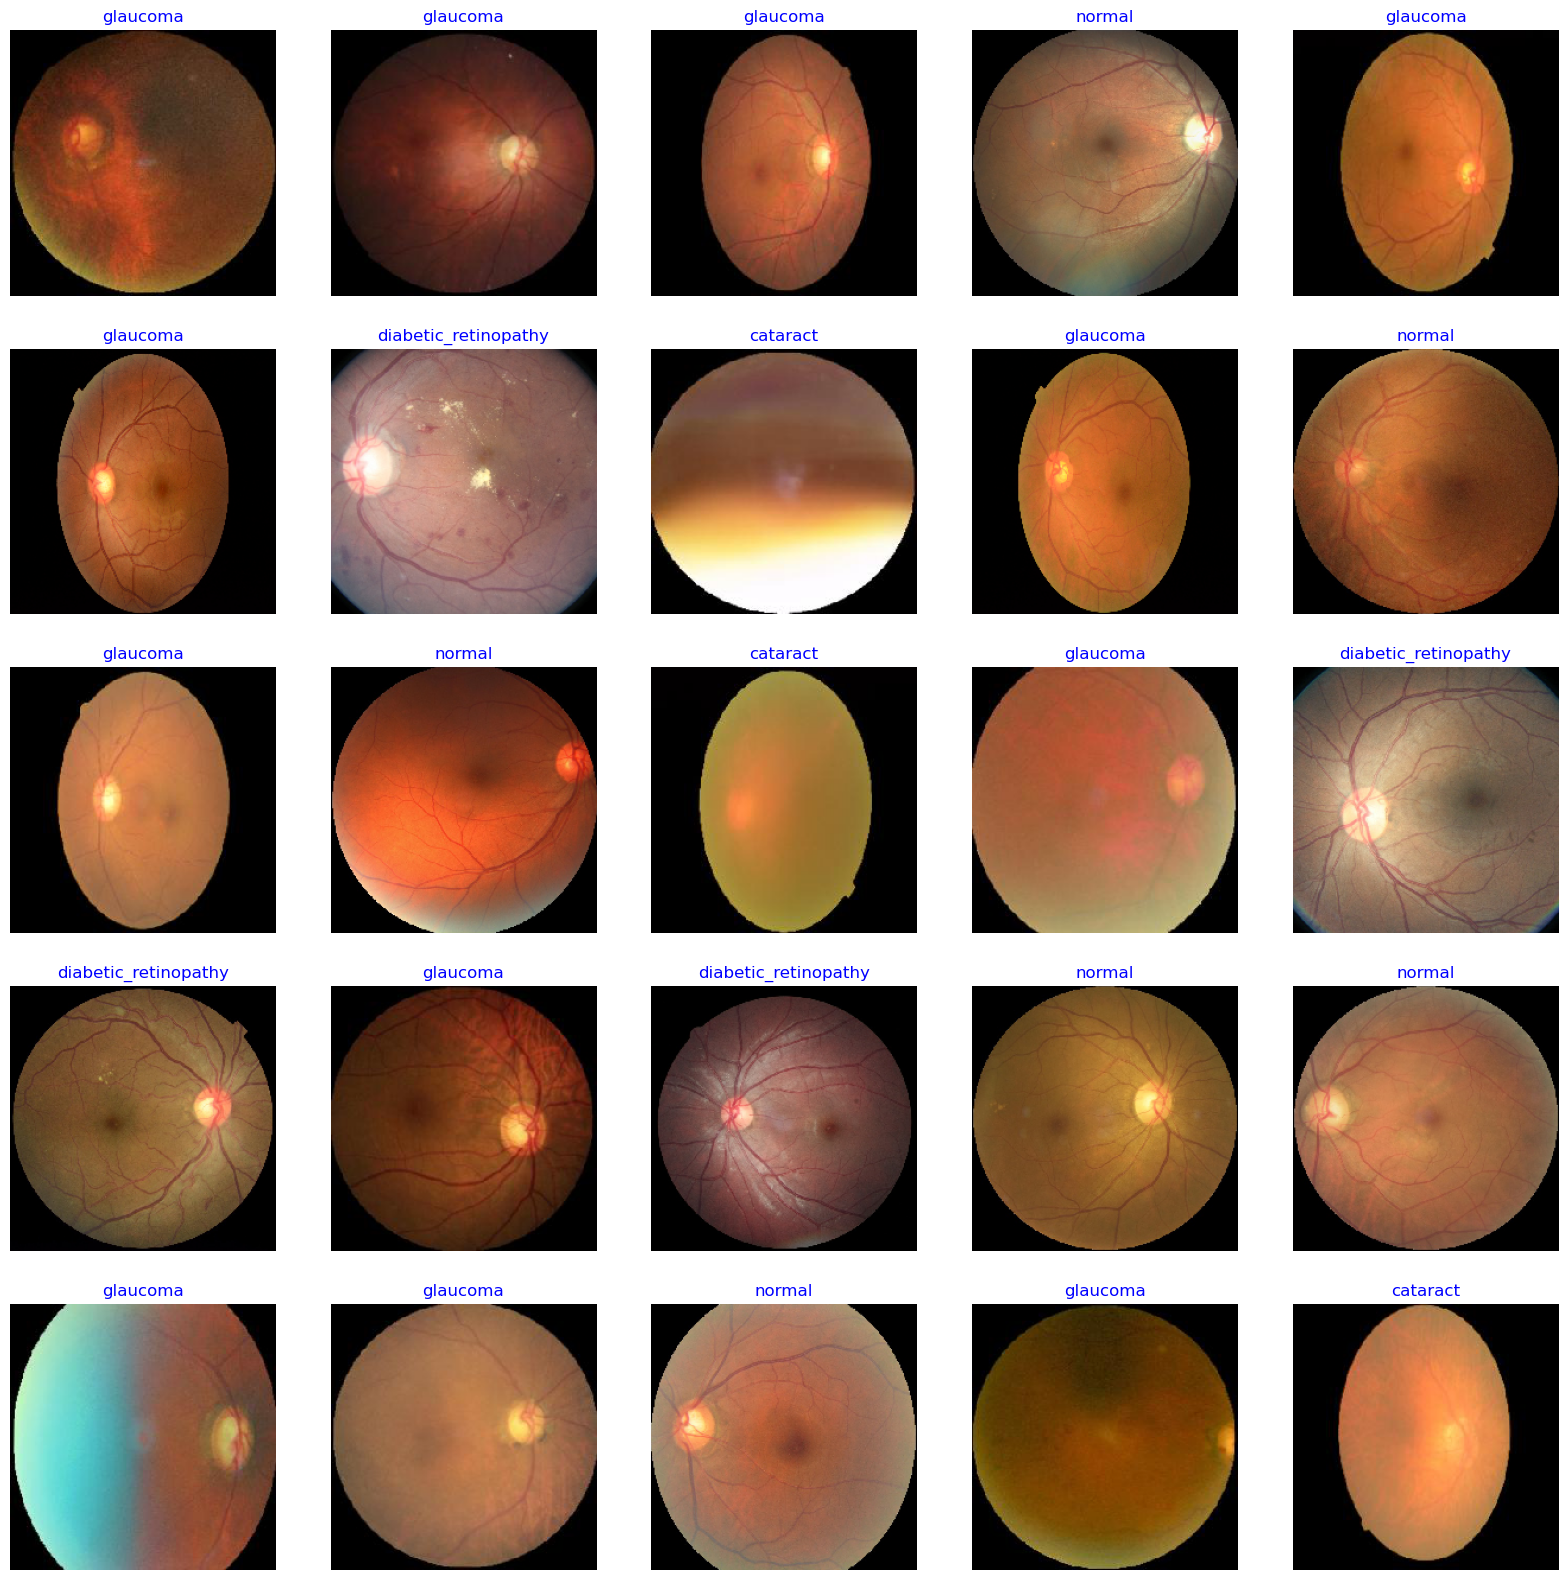

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb3 (Functional)  (None, 1536)             10783535  
                                                                 
 batch_normalization_2 (Batc  (None, 1536)             6144      
 hNormalization)                                                 
                                                                 
 dense_4 (Dense)             (None, 256)               393472    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_5 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 11,184,179
Trainable params: 11,093,804
Non-trainable params: 90,375
_____________________________________

 n


 Epoch     Loss   Accuracy  V_loss    V_acc     LR     Next LR  Monitor  % Improv  Duration


2026-01-12 07:40:49.630576: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_2/efficientnetb3/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


 1 /40     7.396   77.676  12.82939  24.645   0.00100  0.00100  accuracy     0.00    98.13  
 2 /40     5.378   90.454   7.34720  24.645   0.00100  0.00100  val_loss    42.73    45.14  
 3 /40     4.213   93.240   5.54744  27.962   0.00100  0.00100  val_loss    24.50    45.04  
 4 /40     3.373   94.130   5.10117  27.251   0.00100  0.00100  val_loss     8.04    44.90  
 5 /40     2.696   95.938   3.61329  47.156   0.00100  0.00100  val_loss    29.17    45.20  
 6 /40     2.162   95.760   3.00251  53.555   0.00100  0.00100  val_loss    16.90    45.42  
 7 /40     1.743   96.680   2.83585  38.863   0.00100  0.00100  val_loss     5.55    44.46  
 8 /40     1.401   97.510   1.96567  70.853   0.00100  0.00100  val_loss    30.69    44.63  
 9 /40     1.144   97.361   1.52170  77.962   0.00100  0.00100  val_loss    22.59    45.00  
10 /40     0.919   98.280   2.12107  51.422   0.00100  0.00050  val_loss    -39.39   45.12  
11 /40     0.789   98.162   1.31134  77.962   0.00050  0.00050  val_lo

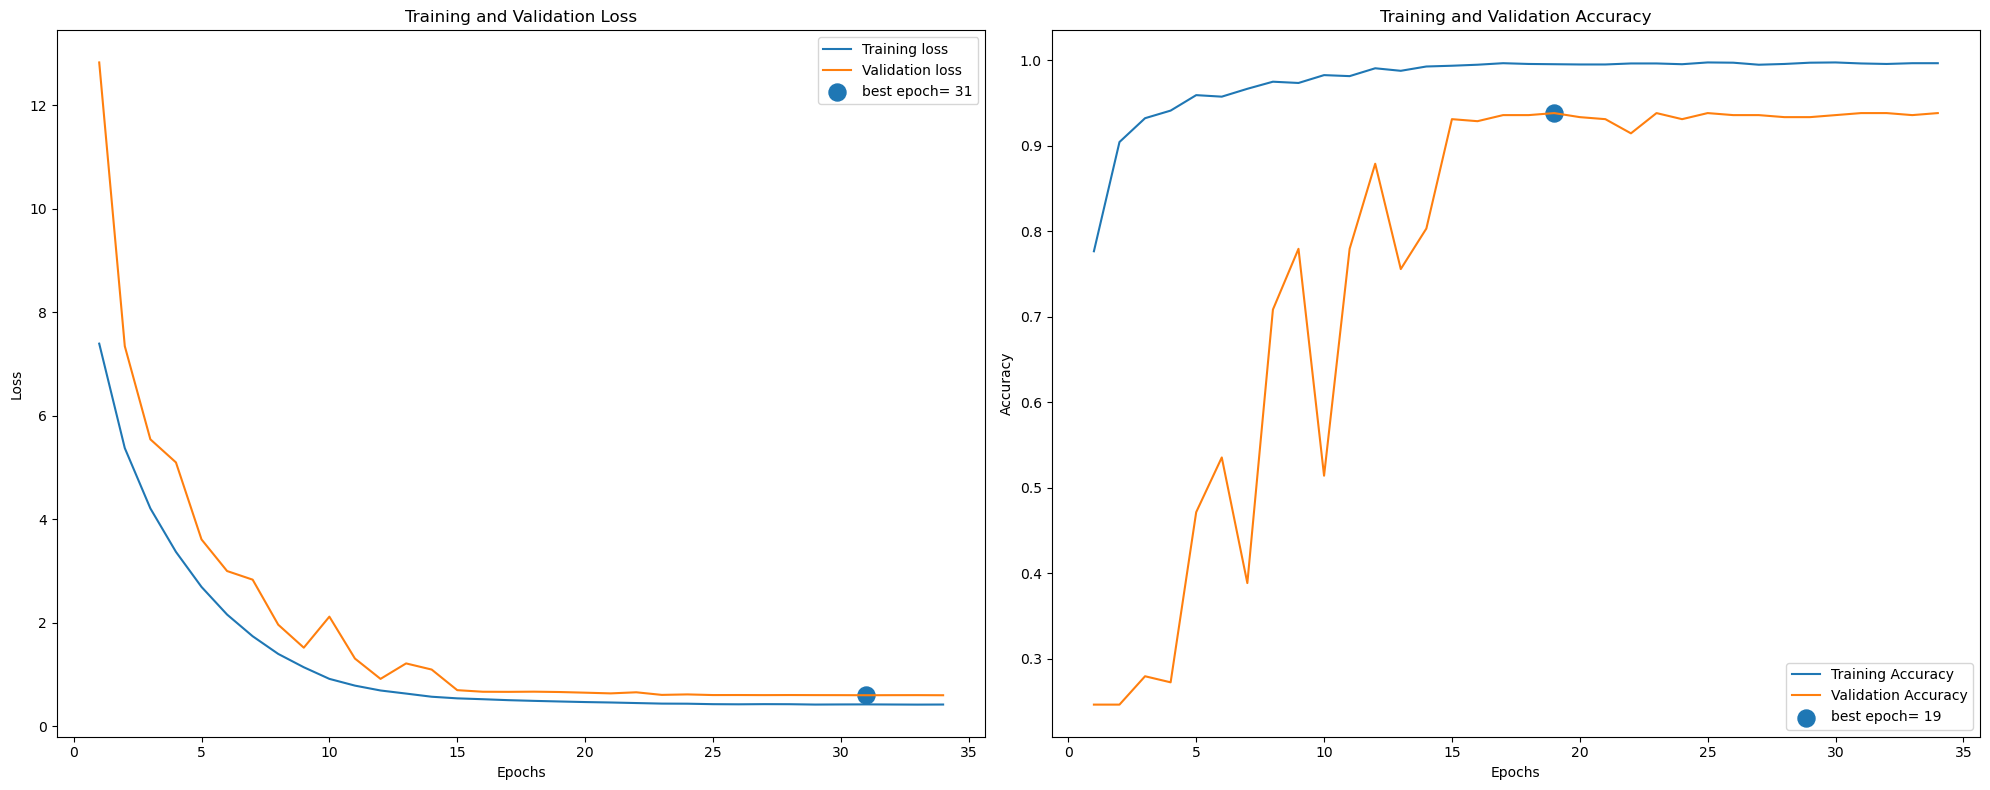

211/211 [==============================] - 6s 28ms/step - loss: 0.5617 - accuracy: 0.9479

Train Loss: 0.3968160152435303  Train Acc: 0.9997035264968872
Valid Loss: 0.6026313900947571  Valid Acc: 0.9383886456489563
Test  Loss: 0.5617178678512573  Test  Acc: 0.9478672742843628
211/211 [==============================] - 8s 26ms/step
Confusion Matrix, Without Normalization
[[102   0   1   1]
 [  0 110   0   0]
 [  1   0  90  10]
 [  4   0   5  98]]


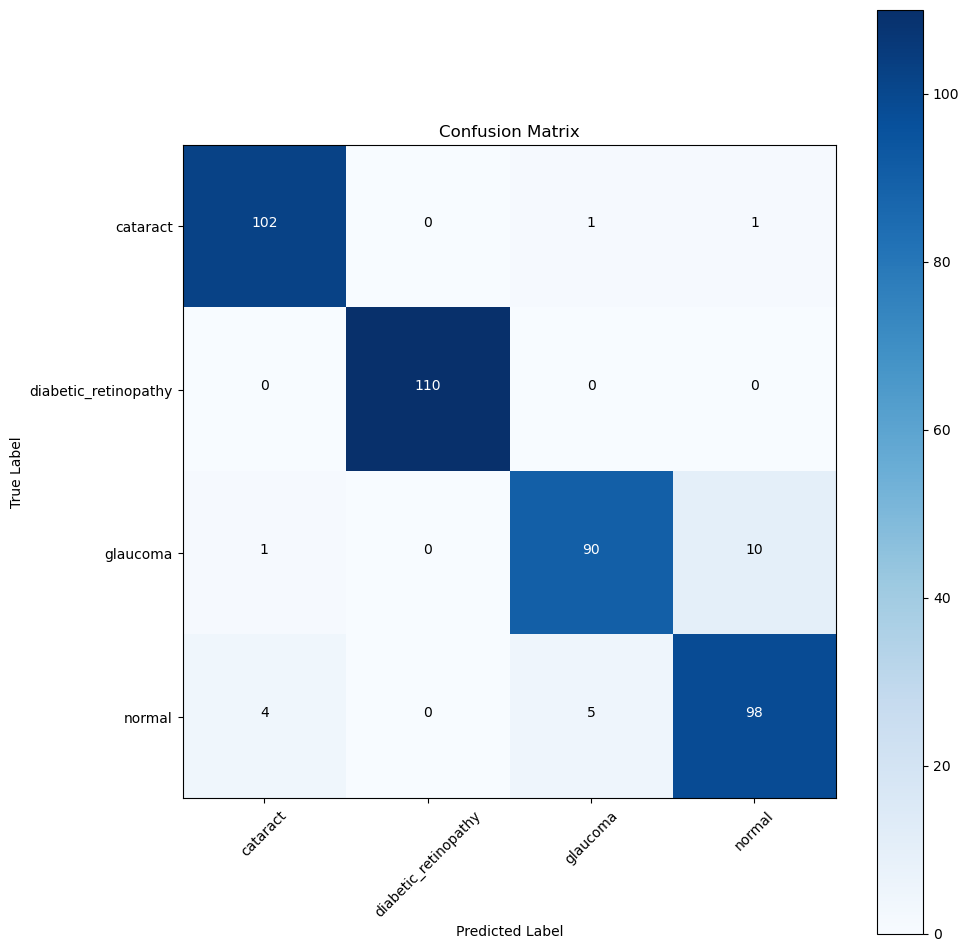

                      precision    recall  f1-score   support

            cataract       0.95      0.98      0.97       104
diabetic_retinopathy       1.00      1.00      1.00       110
            glaucoma       0.94      0.89      0.91       101
              normal       0.90      0.92      0.91       107

            accuracy                           0.95       422
           macro avg       0.95      0.95      0.95       422
        weighted avg       0.95      0.95      0.95       422



In [9]:


# ---------------------------
# 0) System / general libs
# ---------------------------
import os, time, shutil, pathlib, itertools, warnings
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------
# 1) Deep Learning libs
# ---------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

print("modules loaded")

# ---------------------------
# 2) Optional: install LIME/SHAP if missing (Kaggle safe)
# ---------------------------
def _pip_install(pkg):
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import lime
    from lime import lime_image
except Exception:
    print("Installing LIME...")
    _pip_install("lime")
    from lime import lime_image

try:
    import shap
except Exception:
    print("Installing SHAP...")
    _pip_install("shap")
    import shap

# For LIME visualization
from skimage.segmentation import mark_boundaries

# ============================================================
# 3) Data utilities (paths -> dataframe -> split)
# ============================================================
def define_paths(data_dir):
    filepaths, labels = [], []
    folds = os.listdir(data_dir)
    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        if not os.path.isdir(foldpath):
            continue
        for file in os.listdir(foldpath):
            fpath = os.path.join(foldpath, file)
            filepaths.append(fpath)
            labels.append(fold)
    return filepaths, labels

def define_df(files, classes):
    return pd.concat([pd.Series(files, name="filepaths"),
                      pd.Series(classes, name="labels")], axis=1)

def split_data(data_dir, seed=123):
    files, classes = define_paths(data_dir)
    df = define_df(files, classes)
    strat = df["labels"]
    train_df, dummy_df = train_test_split(
        df, train_size=0.8, shuffle=True, random_state=seed, stratify=strat
    )
    strat = dummy_df["labels"]
    valid_df, test_df = train_test_split(
        dummy_df, train_size=0.5, shuffle=True, random_state=seed, stratify=strat
    )
    return train_df, valid_df, test_df

def create_gens(train_df, valid_df, test_df, batch_size):
    """
    Uses rescale=1/255 so inputs match manuscript normalization ([0,1]).
    """
    img_size = (224, 224)
    color = "rgb"

    ts_length = len(test_df)
    test_batch_size = max(sorted([
        ts_length // n for n in range(1, ts_length + 1)
        if ts_length % n == 0 and ts_length / n <= 80
    ]))
    test_steps = ts_length // test_batch_size

    # Consistent normalization
    tr_gen = ImageDataGenerator(rescale=1.0/255.0, horizontal_flip=True)
    ts_gen = ImageDataGenerator(rescale=1.0/255.0)

    train_gen = tr_gen.flow_from_dataframe(
        train_df, x_col="filepaths", y_col="labels",
        target_size=img_size, class_mode="categorical",
        color_mode=color, shuffle=True, batch_size=batch_size
    )
    valid_gen = ts_gen.flow_from_dataframe(
        valid_df, x_col="filepaths", y_col="labels",
        target_size=img_size, class_mode="categorical",
        color_mode=color, shuffle=True, batch_size=batch_size
    )
    test_gen = ts_gen.flow_from_dataframe(
        test_df, x_col="filepaths", y_col="labels",
        target_size=img_size, class_mode="categorical",
        color_mode=color, shuffle=False, batch_size=test_batch_size
    )

    return train_gen, valid_gen, test_gen, test_steps

def show_images(gen, max_show=25):
    g_dict = gen.class_indices
    classes = list(g_dict.keys())
    images, labels = next(gen)

    sample = min(len(labels), max_show)
    plt.figure(figsize=(20, 20))
    for i in range(sample):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i])  # already [0,1] due to rescale
        index = np.argmax(labels[i])
        plt.title(classes[index], color="blue", fontsize=12)
        plt.axis("off")
    plt.show()

# ============================================================
# 4) Training callback (fixed indentation bug)
# ============================================================
class MyCallback(keras.callbacks.Callback):
    def __init__(self, model, patience, stop_patience, threshold, factor, batches, epochs, ask_epoch):
        super().__init__()
        self.model = model
        self.patience = patience
        self.stop_patience = stop_patience
        self.threshold = threshold
        self.factor = factor
        self.batches = batches
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch

        self.count = 0
        self.stop_count = 0
        self.best_epoch = 1
        self.initial_lr = float(tf.keras.backend.get_value(model.optimizer.lr))
        self.highest_tracc = 0.0
        self.lowest_vloss = np.inf
        self.best_weights = self.model.get_weights()

    def on_train_begin(self, logs=None):
        msg = "Do you want model asks you to halt the training [y/n] ?"
        print(msg)
        ans = input("")
        self.ask_permission = 1 if ans in ["Y", "y"] else 0

        header = "{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}".format(
            "Epoch", "Loss", "Accuracy", "V_loss", "V_acc", "LR", "Next LR", "Monitor", "% Improv", "Duration"
        )
        print(header)
        self.start_time = time.time()

    def on_train_end(self, logs=None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))
        print(f"training elapsed time was {int(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds")
        self.model.set_weights(self.best_weights)

    def on_train_batch_end(self, batch, logs=None):
        acc = logs.get("accuracy", 0) * 100
        loss = logs.get("loss", 0)
        msg = "{0:20s}processing batch {1:} of {2:5s}-   accuracy=  {3:5.3f}   -   loss: {4:8.5f}".format(
            " ", str(batch), str(self.batches), acc, loss
        )
        print(msg, "\r", end="")

    def on_epoch_begin(self, epoch, logs=None):
        self.ep_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        lr = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        current_lr = lr

        acc = logs.get("accuracy", 0)
        v_acc = logs.get("val_accuracy", 0)
        loss = logs.get("loss", 0)
        v_loss = logs.get("val_loss", np.inf)

        if acc < self.threshold:
            monitor = "accuracy"
            pimprov = 0.0 if self.highest_tracc == 0 else (acc - self.highest_tracc) * 100 / self.highest_tracc

            if acc > self.highest_tracc:
                self.highest_tracc = acc
                self.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr)
                    self.count = 0
                    self.stop_count += 1
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count += 1
        else:
            monitor = "val_loss"
            pimprov = 0.0 if self.lowest_vloss == np.inf else (self.lowest_vloss - v_loss) * 100 / self.lowest_vloss

            if v_loss < self.lowest_vloss:
                self.lowest_vloss = v_loss
                self.best_weights = self.model.get_weights()  # fixed indentation
                self.count = 0
                self.stop_count = 0
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    self.stop_count += 1
                    self.count = 0
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr)
                else:
                    self.count += 1

                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f"{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc * 100:^9.3f}{v_loss:^9.5f}{v_acc * 100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}"
        print(msg)

        if self.stop_count > self.stop_patience - 1:
            print(f" training halted at epoch {epoch + 1} after {self.stop_patience} LR adjustments with no improvement")
            self.model.stop_training = True
        else:
            if self.ask_epoch is not None and self.ask_permission != 0:
                if epoch + 1 >= self.ask_epoch:
                    print("enter H to halt training or an integer for number of epochs to run then ask again")
                    ans = input("")
                    if ans.lower() == "h":
                        print(f"training halted at epoch {epoch + 1} due to user input")
                        self.model.stop_training = True
                    else:
                        try:
                            ans = int(ans)
                            self.ask_epoch += ans
                            print(f" training will continue until epoch {str(self.ask_epoch)}")
                            header = "{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}".format(
                                "Epoch", "Loss", "Accuracy", "V_loss", "V_acc", "LR", "Next LR", "Monitor", "% Improv", "Duration"
                            )
                            print(header)
                        except Exception:
                            print("Invalid input")

def plot_training(hist):
    tr_acc = hist.history["accuracy"]
    tr_loss = hist.history["loss"]
    val_acc = hist.history["val_accuracy"]
    val_loss = hist.history["val_loss"]

    index_loss = int(np.argmin(val_loss))
    index_acc = int(np.argmax(val_acc))
    Epochs = [i + 1 for i in range(len(tr_acc))]

    plt.figure(figsize=(20, 8))

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, label="Training loss")
    plt.plot(Epochs, val_loss, label="Validation loss")
    plt.scatter(index_loss + 1, val_loss[index_loss], s=150, label=f"best epoch= {index_loss + 1}")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, label="Training Accuracy")
    plt.plot(Epochs, val_acc, label="Validation Accuracy")
    plt.scatter(index_acc + 1, val_acc[index_acc], s=150, label=f"best epoch= {index_acc + 1}")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, classes, normalize=False, title="Confusion Matrix", cmap=plt.cm.Blues):
    plt.figure(figsize=(10, 10))
    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized Confusion Matrix")
    else:
        print("Confusion Matrix, Without Normalization")

    print(cm)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

# ============================================================
# 5) Load data
# ============================================================
data_dir = "/kaggle/input/eye-diseases-classification/dataset"

train_df, valid_df, test_df = split_data(data_dir)
batch_size = 40
train_gen, valid_gen, test_gen, test_steps = create_gens(train_df, valid_df, test_df, batch_size)

show_images(train_gen)

# ============================================================
# 6) Build model (choose ONE base model)
# ============================================================
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))

# Pick one base model (uncomment desired)
base_model = tf.keras.applications.EfficientNetB3(include_top=False, weights="imagenet", input_shape=img_shape, pooling="max")
#base_model = tf.keras.applications.MobileNet(include_top=False, weights="imagenet", input_shape=img_shape, pooling="max")
#base_model = tf.keras.applications.InceptionResNetV2(include_top=False, weights="imagenet", input_shape=img_shape, pooling="max")
#base_model = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_shape=img_shape, pooling="max")
#base_model = tf.keras.applications.DenseNet121(include_top=False, weights="imagenet", input_shape=img_shape, pooling="max")
# base_model = tf.keras.applications.Xception(include_top=False, weights="imagenet", input_shape=img_shape, pooling="max")
# base_model = tf.keras.applications.VGG19(include_top=False, weights="imagenet", input_shape=img_shape, pooling="max")
#base_model = tf.keras.applications.InceptionV3(include_top=False, weights="imagenet", input_shape=img_shape, pooling="max")

model = Sequential([
    base_model,
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    Dense(256,
          kernel_regularizer=regularizers.l2(l=0.016),
          activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006),
          activation="relu"),
    Dropout(rate=0.45, seed=123),
    Dense(class_count, activation="softmax")
])

model.compile(Adamax(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# ============================================================
# 7) Train
# ============================================================
epochs = 40
patience = 1
stop_patience = 3
threshold = 0.9
factor = 0.5
ask_epoch = 5
batches = int(np.ceil(len(train_gen.labels) / batch_size))

callbacks = [MyCallback(model=model, patience=patience, stop_patience=stop_patience,
                        threshold=threshold, factor=factor, batches=batches,
                        epochs=epochs, ask_epoch=ask_epoch)]

history = model.fit(
    x=train_gen,
    epochs=epochs,
    verbose=0,
    callbacks=callbacks,
    validation_data=valid_gen,
    shuffle=False
)

plot_training(history)

# ============================================================
# 8) Evaluate + Reports
# ============================================================
train_score = model.evaluate(train_gen, steps=test_steps, verbose=1)
valid_score = model.evaluate(valid_gen, steps=test_steps, verbose=1)
test_score  = model.evaluate(test_gen,  steps=test_steps, verbose=1)

print("\nTrain Loss:", train_score[0], " Train Acc:", train_score[1])
print("Valid Loss:", valid_score[0], " Valid Acc:", valid_score[1])
print("Test  Loss:", test_score[0],  " Test  Acc:", test_score[1])

preds = model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)

g_dict = test_gen.class_indices
classes = list(g_dict.keys())

cm = confusion_matrix(test_gen.classes, y_pred)
plot_confusion_matrix(cm=cm, classes=classes, title="Confusion Matrix")

print(classification_report(test_gen.classes, y_pred, target_names=classes))




  0%|          | 0/1500 [00:00<?, ?it/s]

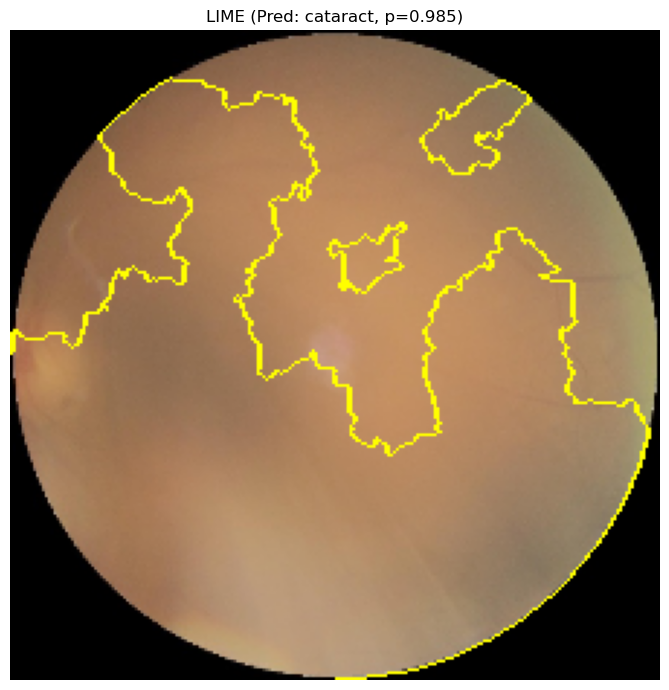

[LIME] Saved: lime_output.png
[LIME] Predicted class: cataract (p=0.9846)


<Figure size 640x480 with 0 Axes>

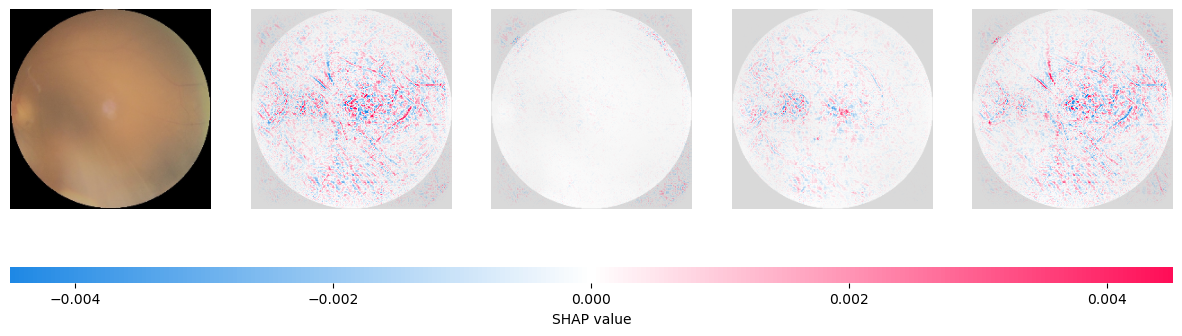

[SHAP] Saved: shap_output.png
[SHAP] Predicted class: cataract (p=0.9846)

Done: LIME and SHAP explanations generated.


In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ---------- Ensure LIME + SHAP installed ----------
def _pip_install(pkg):
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    from lime import lime_image
except Exception:
    print("Installing LIME...")
    _pip_install("lime")
    from lime import lime_image

try:
    import shap
except Exception:
    print("Installing SHAP...")
    _pip_install("shap")
    import shap

from skimage.segmentation import mark_boundaries


# ============================================================
# 1) LIME (instance-level interpretability)
# ============================================================
def lime_predict_fn(images_uint8):
    """
    LIME sends images as uint8 arrays (N,H,W,3) in [0..255].
    We must convert them to float32 [0..1] before passing to model.

    Returns probabilities (N, num_classes).
    """
    imgs = images_uint8.astype(np.float32) / 255.0
    return model.predict(imgs, verbose=0)

def run_lime_on_image(
    image_path,
    class_names,
    num_samples=1500,
    num_features=12,
    hide_color=0,
    top_labels=1,
    save_path="lime_output.png"
):
    """
    Generates LIME explanation for the model's predicted class on one image.
    Saves a figure that highlights influential superpixels.
    """
    # Load image as RGB uint8
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")
    img_bgr = cv2.resize(img_bgr, (224, 224))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Model prediction (for labeling)
    x = np.expand_dims(img_rgb.astype(np.float32) / 255.0, axis=0)
    probs = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_name = class_names[pred_idx]
    pred_p = float(probs[pred_idx])
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_rgb,
        classifier_fn=lime_predict_fn,
        top_labels=top_labels,
        hide_color=hide_color,
        num_samples=num_samples
    )

    # Get explanation mask for predicted class
    temp, mask = explanation.get_image_and_mask(
        label=pred_idx,
        positive_only=True,      # show only positive contributions
        num_features=num_features,
        hide_rest=False
    )

    lime_vis = mark_boundaries(temp / 255.0, mask)

    plt.figure(figsize=(7, 7))
    plt.title(f"LIME (Pred: {pred_name}, p={pred_p:.3f})")
    plt.imshow(lime_vis)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

    print(f"[LIME] Saved: {save_path}")
    print(f"[LIME] Predicted class: {pred_name} (p={pred_p:.4f})")

# ============================================================
# 2) SHAP (feature-attribution / instance-level)
# ============================================================
def sample_background_from_generator(gen, n=32):
    """
    Collects n images from a generator as SHAP background.
    Your generators are rescaled to [0,1] if you used rescale=1/255.
    """
    Xb = []
    while len(Xb) < n:
        x_batch, _ = next(gen)
        for i in range(x_batch.shape[0]):
            Xb.append(x_batch[i])
            if len(Xb) >= n:
                break
    return np.stack(Xb, axis=0).astype(np.float32)

def run_shap_on_image(
    image_path,
    class_names,
    background_data,
    save_path="shap_output.png"
):
    """
    Uses SHAP GradientExplainer to compute attributions for one image.
    Saves SHAP image plot.
    """
    # Load image as RGB float32 in [0,1]
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")
    img_bgr = cv2.resize(img_bgr, (224, 224))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    x = np.expand_dims(img_rgb.astype(np.float32) / 255.0, axis=0)

    # Predict class for reporting
    probs = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_name = class_names[pred_idx]
    pred_p = float(probs[pred_idx])
        # GradientExplainer is typically stable for TF/Keras
    explainer = shap.GradientExplainer(model, background_data)

    # shap_values is a list (one array per class): each has shape (1,H,W,3)
    shap_values = explainer.shap_values(x)

    # Save SHAP plot
    # NOTE: shap.image_plot will show attributions for all classes by default.
    # This is acceptable for reviewer response; optionally you can focus on pred_idx.
    plt.figure()
    shap.image_plot(shap_values, x, show=False)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"[SHAP] Saved: {save_path}")
    print(f"[SHAP] Predicted class: {pred_name} (p={pred_p:.4f})")


# ============================================================
# 3) Run XAI on a sample image (edit as needed)
# ============================================================
# Use the same image you used for Grad-CAM
image_path = "/kaggle/input/eye-diseases-classification/dataset/cataract/103_left.jpg"

# Your class names from generator
# classes = list(test_gen.class_indices.keys())

# -------- Run LIME --------
run_lime_on_image(
    image_path=image_path,
    class_names=classes,
    num_samples=1500,      # increase for more stable explanations
    num_features=12,
    save_path="lime_output.png"
)
# -------- Run SHAP --------
# Use training generator as background (recommended)
background = sample_background_from_generator(train_gen, n=32)

run_shap_on_image(
    image_path=image_path,
    class_names=classes,
    background_data=background,
    save_path="shap_output.png"
)

print("\nDone: LIME and SHAP explanations generated.")